# Oasis Infobyte Internship

# Task 3: Car Price Prediction with Machine Learning

## Internship Domain
**Data Science**

---

## Project Overview

The price of a used car depends on several factors such as its age, fuel type, transmission, ownership history, and current market value. Predicting the selling price of a car is an important regression problem in machine learning that helps buyers and sellers estimate a fair market price.

In this project, we build regression models to predict the selling price of used cars using historical data. The project also includes data cleaning, feature engineering, exploratory data analysis (EDA), feature encoding, model evaluation, and comparison of multiple machine learning algorithms.

---

## Objectives

- Load and inspect the car price dataset
- Perform data cleaning and preprocessing
- Create new features such as Car Age and Brand
- Perform exploratory data analysis (EDA)
- Encode categorical variables
- Train multiple regression models
- Compare model performance using evaluation metrics
- Identify the most important features affecting car prices

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Google Colab (Jupyter Notebook)

---

## Dataset

**car data.csv**

---

## Author

**Anirban Garai**

Oasis Infobyte Internship

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Importing Libraries

The following Python libraries are required for this project.

### NumPy
Used for numerical computations.

### Pandas
Used for loading, cleaning, and manipulating datasets.

### Matplotlib
Used for creating visualizations.

### Seaborn
Used for advanced statistical plots and attractive graphs.

These libraries provide the foundation for data analysis and machine learning.

In [2]:
# Setting visualization style

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


# Loading the Dataset

The dataset used in this project contains information about used cars, including their selling price, fuel type, transmission, ownership history, and other important attributes.

These features will be used to predict the selling price of a car using machine learning regression models.

In [4]:
# Load Dataset

df = pd.read_csv("car data.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


# Display Dataset

Let's display the first few rows to understand the structure of the dataset.

In [5]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


# Dataset Information

The `info()` function provides useful information about the dataset, including:

- Number of rows and columns
- Data types
- Non-null values
- Memory usage

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


# Shape of Dataset

The shape of the dataset tells us the total number of rows and columns available for analysis.

In [7]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

Rows : 301
Columns : 9


# Column Names

Let's inspect all the columns present in the dataset.

In [8]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

# Data Types

Checking the data type of each column helps us identify numerical and categorical features before preprocessing.

In [9]:
df.dtypes

,0
Car_Name,object
Year,int64
Selling_Price,float64
Present_Price,float64
Driven_kms,int64
Fuel_Type,object
Selling_type,object
Transmission,object
Owner,int64


# Statistical Summary

The `describe()` function provides summary statistics for numerical columns, including:

- Count
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

This helps us understand the distribution of numerical variables.

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Display Last 10 Records

Viewing the last few rows helps verify that the dataset has been loaded correctly.

In [11]:
df.tail(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
291,brio,2015,5.40,6.10,31427,Petrol,Dealer,Manual,0
292,jazz,2016,6.40,8.40,12000,Petrol,Dealer,Manual,0
293,city,2010,3.25,9.90,38000,Petrol,Dealer,Manual,0
294,amaze,2014,3.75,6.80,33019,Petrol,Dealer,Manual,0
295,city,2015,8.55,13.09,60076,Diesel,Dealer,Manual,0
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.90,5464,Petrol,Dealer,Manual,0


# Sample Records

Randomly sampling records provides another quick overview of the dataset.

In [12]:
df.sample(10)

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
102,KTM RC200,2017,1.65,1.780,4000,Petrol,Individual,Manual,0
140,Honda CBR 150,2013,0.60,1.200,32000,Petrol,Individual,Manual,0
191,Bajaj Discover 125,2012,0.20,0.570,25000,Petrol,Individual,Manual,1
141,Bajaj Avenger 150 street,2016,0.60,0.800,20000,Petrol,Individual,Manual,0
205,grand i10,2016,5.25,5.700,3493,Petrol,Dealer,Manual,1
199,Honda CB Shine,2007,0.12,0.580,53000,Petrol,Individual,Manual,0
5,vitara brezza,2018,9.25,9.830,2071,Diesel,Dealer,Manual,0
146,Hero Extreme,2014,0.55,0.787,15000,Petrol,Individual,Manual,0
127,Bajaj Avenger 150,2016,0.75,0.800,7000,Petrol,Individual,Manual,0
42,sx4,2008,1.95,7.150,58000,Petrol,Dealer,Manual,0


# Checking Basic Dataset Information

Let's inspect the dimensions of the dataset and count the number of unique values in each column.

In [13]:
print("Dataset Shape :", df.shape)

print("\nUnique Values\n")

for col in df.columns:
    print(col, ":", df[col].nunique())

Dataset Shape : (301, 9)

Unique Values

Car_Name : 98
Year : 16
Selling_Price : 156
Present_Price : 148
Driven_kms : 206
Fuel_Type : 3
Selling_type : 2
Transmission : 2
Owner : 3


# Target Variable

The target variable is the feature that our machine learning model will predict.

In this project, the target variable is:

**Selling_Price**

All other features will be used as input variables to train regression models.

In [14]:
print("Target Variable :", "Selling_Price")

Target Variable : Selling_Price


# Dataset Overview

From the initial inspection, we understand:

- The number of records and features in the dataset.
- The available numerical and categorical variables.
- The target variable for prediction.
- The overall structure of the dataset.

This provides a solid foundation before proceeding to data cleaning, feature engineering, and exploratory data analysis.

___

# Data Cleaning

Before building machine learning models, it is important to clean and preprocess the dataset.

The following steps will be performed:

- Check for missing values
- Check duplicate records
- Remove duplicate records (if any)
- Verify data consistency

In [15]:
# Checking Missing Values

df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


# Missing Values Analysis

Missing values can reduce the performance of machine learning models.

Let's visualize them using a heatmap.

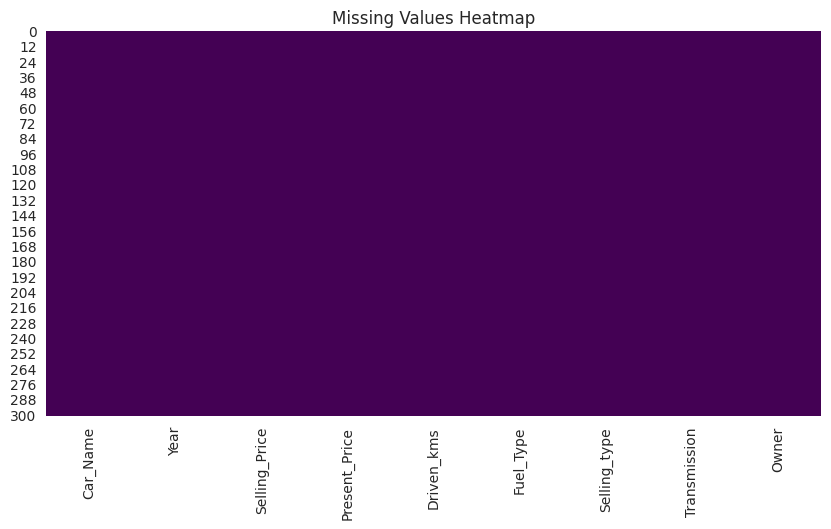

In [16]:
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")

plt.show()

### Observation

- The heatmap helps identify missing values in each column.
- Fortunately, this dataset contains little or no missing data, making preprocessing easier.

# Duplicate Records

Duplicate records can introduce bias into machine learning models.

Let's check whether duplicate rows exist.

In [17]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 2


# Removing Duplicate Records

In [18]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (299, 9)


# Feature Engineering

Feature engineering creates new variables that improve model performance.

In this project, we will create:

- Car Age
- Brand

# Creating Car Age

Older cars generally have lower selling prices.

Instead of using the manufacturing year directly, we calculate the age of each car.

In [19]:
current_year = pd.Timestamp.now().year

df["Car_Age"] = current_year - df["Year"]

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


# Extracting Brand Name

The car name contains both the manufacturer and model.

For example:

- Maruti Swift
- Honda City
- Toyota Fortuner

Extracting the manufacturer (brand) can improve prediction performance.

In [20]:
df["Brand"] = df["Car_Name"].str.split().str[0]

df[["Car_Name","Brand"]].head()

,Car_Name,Brand
0,ritz,ritz
1,sx4,sx4
2,ciaz,ciaz
3,wagon r,wagon
4,swift,swift


# Removing Unnecessary Columns

After creating the new features, the original Car_Name and Year columns are no longer required.

In [21]:
df.drop(["Car_Name","Year"], axis=1, inplace=True)

df.head()

,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age,Brand
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12,ritz
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13,sx4
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9,ciaz
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15,wagon
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12,swift


# Updated Dataset Information

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Selling_Price  299 non-null    float64
 1   Present_Price  299 non-null    float64
 2   Driven_kms     299 non-null    int64  
 3   Fuel_Type      299 non-null    object 
 4   Selling_type   299 non-null    object 
 5   Transmission   299 non-null    object 
 6   Owner          299 non-null    int64  
 7   Car_Age        299 non-null    int64  
 8   Brand          299 non-null    object 
dtypes: float64(2), int64(3), object(4)
memory usage: 23.4+ KB


---

# Exploratory Data Analysis (EDA)

EDA helps us understand the characteristics of the dataset through visualizations before training machine learning models.

# Distribution of Selling Price

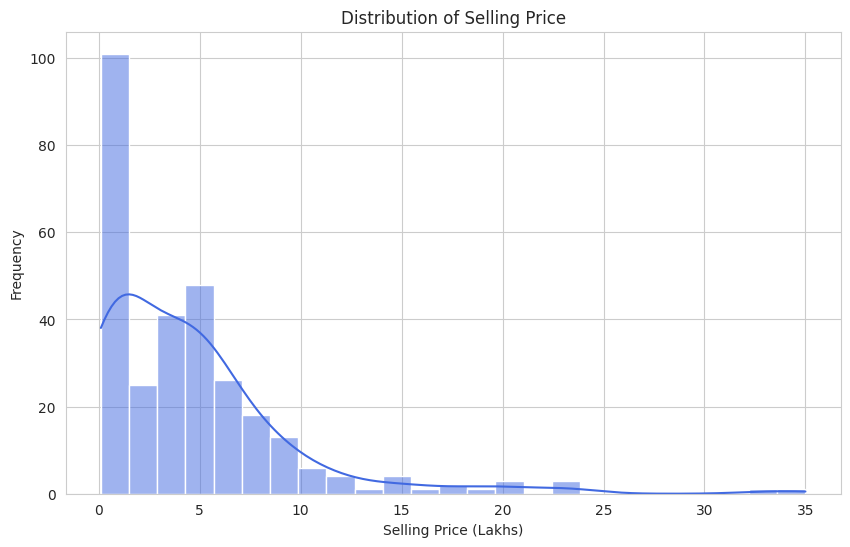

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Selling_Price"],
    bins=25,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Selling Price")

plt.xlabel("Selling Price (Lakhs)")

plt.ylabel("Frequency")

plt.show()

### Observation

- Most cars are concentrated in the lower selling price range.
- Only a few cars have very high selling prices.

# Selling Price by Fuel Type

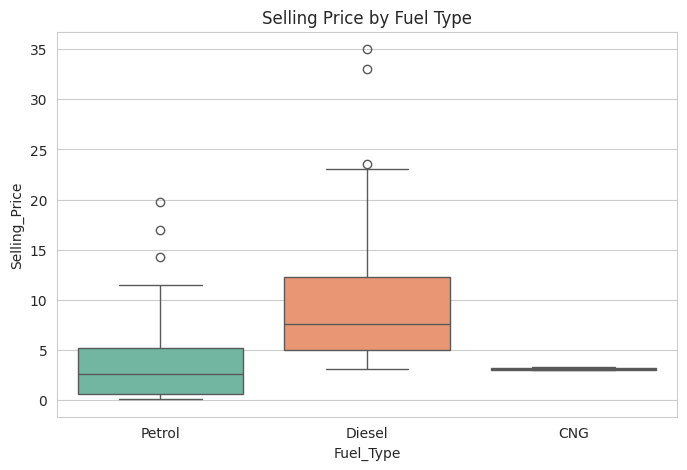

In [24]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Fuel_Type",
    y="Selling_Price",
    palette="Set2"
)

plt.title("Selling Price by Fuel Type")

plt.show()

### Observation

- Different fuel types have different price distributions.
- Diesel and petrol vehicles generally dominate the market.

# Selling Price by Transmission

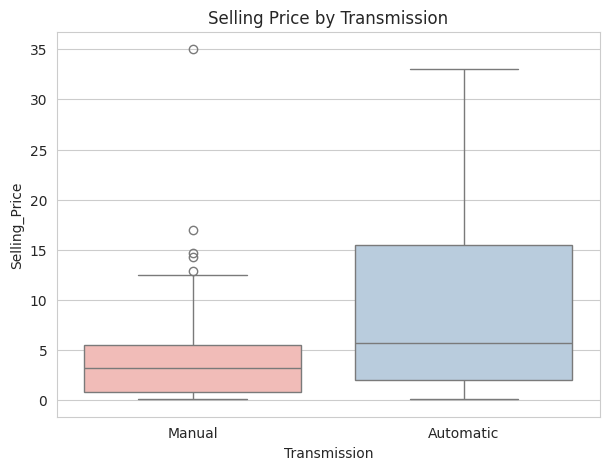

In [25]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Selling_Price",
    palette="Pastel1"
)

plt.title("Selling Price by Transmission")

plt.show()

### Observation

- Automatic cars often have higher selling prices than manual cars.
- Price variation is visible across transmission types.

# Car Age vs Selling Price

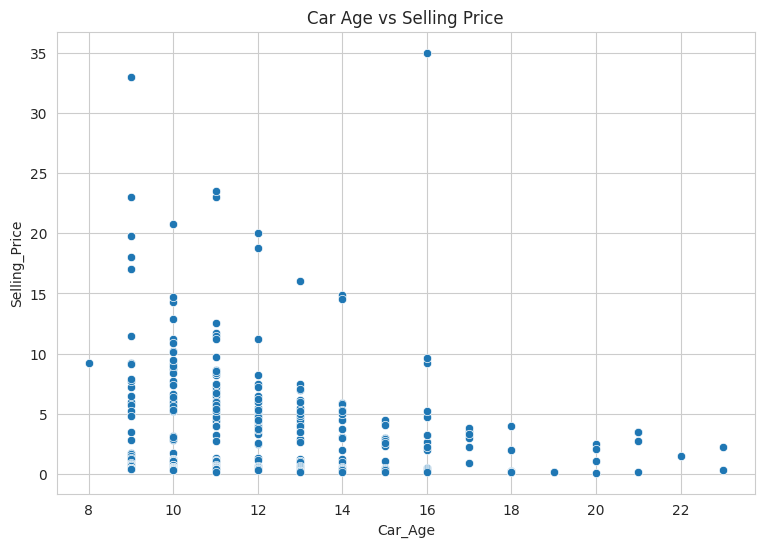

In [26]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Car Age vs Selling Price")

plt.show()

### Observation

- Older cars generally have lower selling prices.
- This indicates a negative relationship between car age and price.

# Present Price vs Selling Price

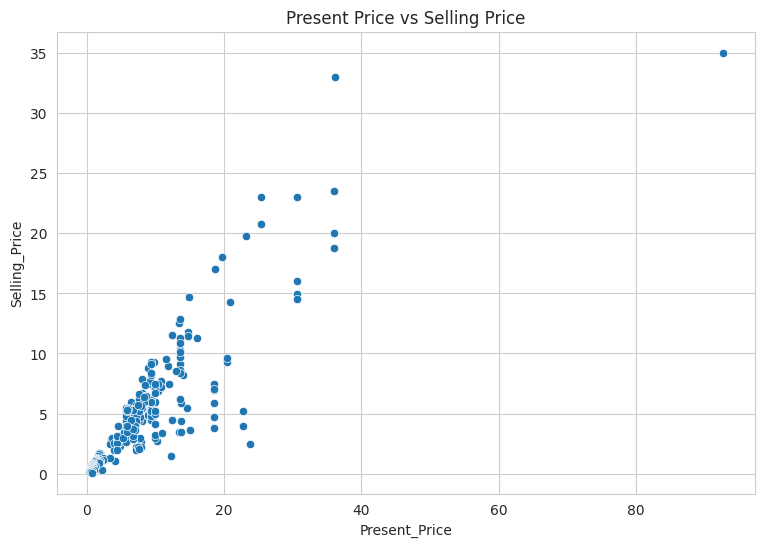

In [27]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Present Price vs Selling Price")

plt.show()

### Observation

- Cars with higher present prices generally have higher selling prices.
- A strong positive relationship is visible.

# Driven Kilometers vs Selling Price

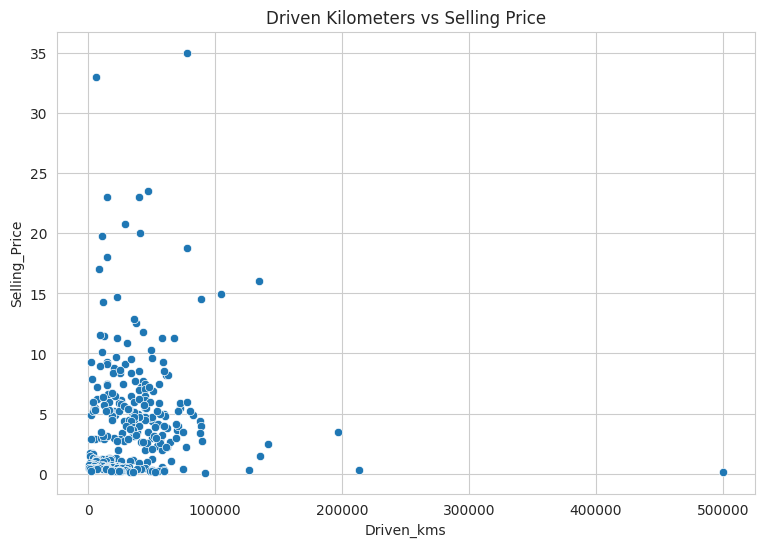

In [28]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Driven_kms",
    y="Selling_Price"
)

plt.title("Driven Kilometers vs Selling Price")

plt.show()

### Observation

- Cars driven for more kilometers generally have lower resale values.
- However, some premium vehicles retain higher prices despite higher mileage.

# Encoding Categorical Variables

Machine learning algorithms require numerical input.

The dataset contains categorical variables such as:

- Fuel Type
- Selling Type
- Transmission
- Brand

These variables will be converted into numerical values using One-Hot Encoding.

In [29]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Selling_type", "Transmission", "Brand"],
    drop_first=True
)

df.head()

,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual,Brand_Activa,...,Brand_land,Brand_omni,Brand_ritz,Brand_s,Brand_swift,Brand_sx4,Brand_verna,Brand_vitara,Brand_wagon,Brand_xcent
0,3.35,5.59,27000,0,12,False,True,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,4.75,9.54,43000,0,13,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,7.25,9.85,6900,0,9,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2.85,4.15,5200,0,15,False,True,False,True,False,...,False,False,False,False,False,False,False,False,True,False
4,4.60,6.87,42450,0,12,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False


# Encoded Dataset Information

Let's verify that all categorical variables have been successfully converted into numerical features.

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Selling_Price            299 non-null    float64
 1   Present_Price            299 non-null    float64
 2   Driven_kms               299 non-null    int64  
 3   Owner                    299 non-null    int64  
 4   Car_Age                  299 non-null    int64  
 5   Fuel_Type_Diesel         299 non-null    bool   
 6   Fuel_Type_Petrol         299 non-null    bool   
 7   Selling_type_Individual  299 non-null    bool   
 8   Transmission_Manual      299 non-null    bool   
 9   Brand_Activa             299 non-null    bool   
 10  Brand_Bajaj              299 non-null    bool   
 11  Brand_Hero               299 non-null    bool   
 12  Brand_Honda              299 non-null    bool   
 13  Brand_Hyosung            299 non-null    bool   
 14  Brand_KTM                299 no

# Correlation Analysis

Correlation helps us understand the relationship between numerical variables.

A heatmap provides an easy way to visualize these relationships.

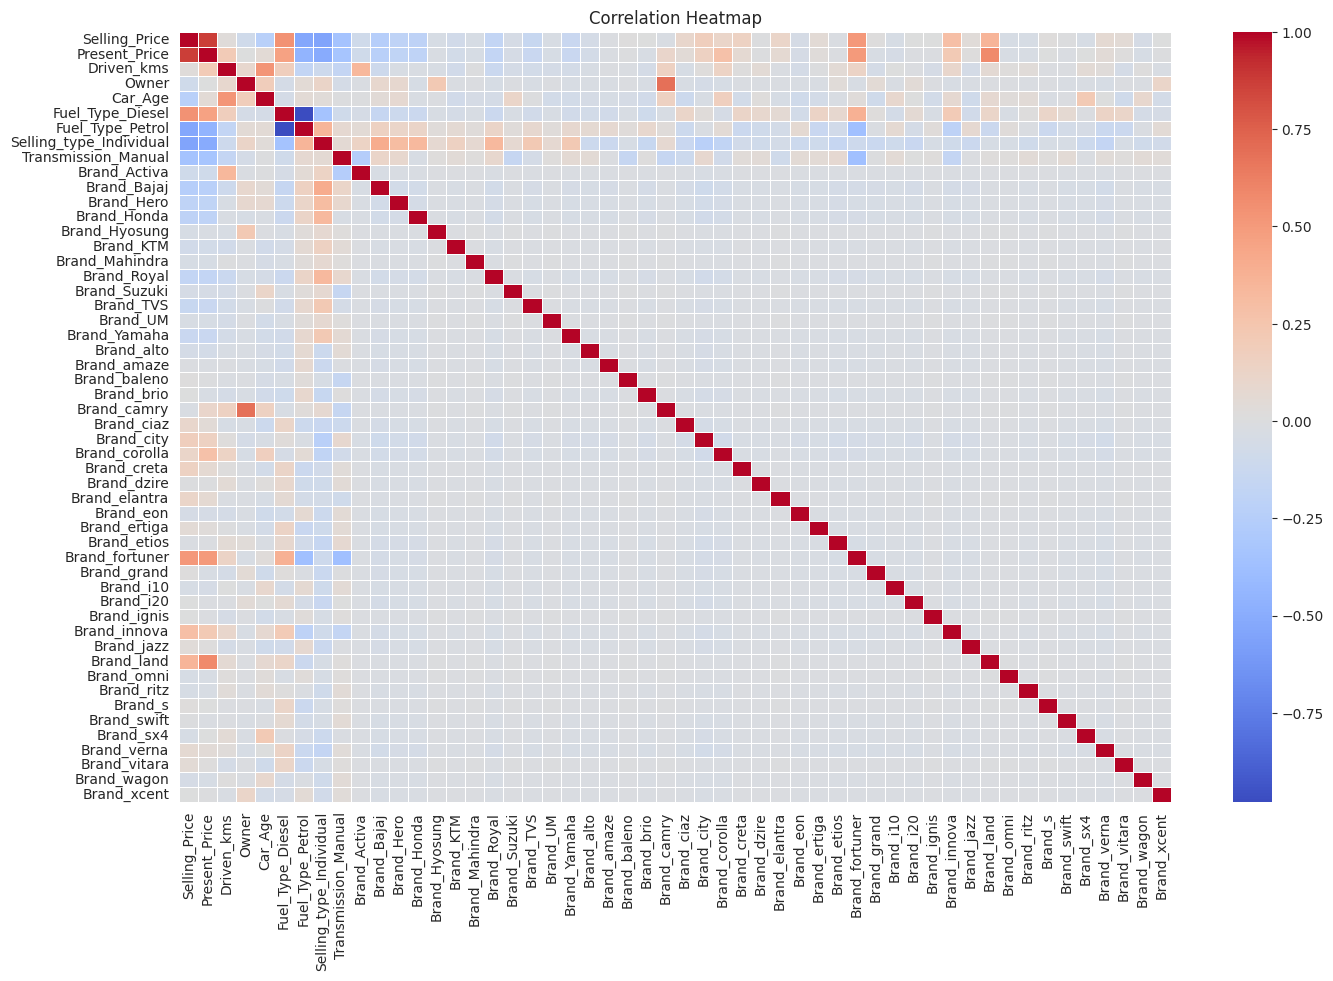

In [31]:
plt.figure(figsize=(16,10))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Positive correlation indicates that two variables increase together.
- Negative correlation indicates an inverse relationship.
- Strongly correlated features often have greater influence on the target variable.

# Feature Selection

The target variable is:

**Selling_Price**

All remaining variables will be used as input features.

In [32]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (299, 51)
Target Shape : (299,)


# Splitting the Dataset

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

This allows us to evaluate the performance of machine learning models on unseen data.

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape[0])

print("Testing Samples :", X_test.shape[0])

Training Samples : 239
Testing Samples : 60


---

# Importing Machine Learning Models

We will train three regression models:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

In [35]:
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model 1: Linear Regression

Linear Regression establishes a linear relationship between the input features and the target variable.

In [36]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

## Evaluating Linear Regression

In [37]:
lr_mae = mean_absolute_error(y_test, lr_prediction)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_prediction))

lr_r2 = r2_score(y_test, lr_prediction)

print("MAE :", round(lr_mae,3))

print("RMSE :", round(lr_rmse,3))

print("R² Score :", round(lr_r2,3))

MAE : 1.808
RMSE : 3.396
R² Score : 0.553


### Observation

The Linear Regression model provides a baseline for comparing more advanced machine learning algorithms.

# Model 2: Random Forest Regressor

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy.

In [38]:
rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

## Evaluating Random Forest

In [39]:
rf_mae = mean_absolute_error(y_test, rf_prediction)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_prediction))

rf_r2 = r2_score(y_test, rf_prediction)

print("MAE :", round(rf_mae,3))

print("RMSE :", round(rf_rmse,3))

print("R² Score :", round(rf_r2,3))

MAE : 1.36
RMSE : 3.307
R² Score : 0.576


### Observation

Random Forest generally captures nonlinear relationships more effectively than Linear Regression.

# Model 3: Gradient Boosting Regressor

Gradient Boosting builds multiple weak learners sequentially, where each new model corrects the errors of the previous one.

In [40]:
gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_prediction = gb_model.predict(X_test)

## Evaluating Gradient Boosting

In [41]:
gb_mae = mean_absolute_error(y_test, gb_prediction)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_prediction))

gb_r2 = r2_score(y_test, gb_prediction)

print("MAE :", round(gb_mae,3))

print("RMSE :", round(gb_rmse,3))

print("R² Score :", round(gb_r2,3))

MAE : 1.19
RMSE : 2.761
R² Score : 0.704


### Observation

Gradient Boosting often achieves excellent predictive performance by combining multiple weak learners into a strong regression model.

# Model Comparison

Now we compare the performance of all three regression models.

In [42]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        lr_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE":[
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2 Score":[
        lr_r2,
        rf_r2,
        gb_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.807787,3.395654,0.552619
1,Random Forest,1.360312,3.307037,0.575665
2,Gradient Boosting,1.189771,2.761189,0.704183


### Observation

- Lower MAE and RMSE indicate better prediction accuracy.
- A higher R² score indicates better model performance.
- The best-performing model will be selected for feature importance analysis and prediction.

---

# Selecting the Best Model

After evaluating all regression models, we select the model with the highest R² score and the lowest prediction errors.

This model will be used for feature importance analysis and prediction.

In [43]:
# Select Best Model

models = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

scores = {
    "Linear Regression": lr_r2,
    "Random Forest": rf_r2,
    "Gradient Boosting": gb_r2
}

best_model_name = max(scores, key=scores.get)

best_model = models[best_model_name]

print("Best Model :", best_model_name)

print("Best R² Score :", round(scores[best_model_name],3))

Best Model : Gradient Boosting
Best R² Score : 0.704


# Feature Importance

Feature importance helps us understand which variables contribute the most to predicting car prices.

Tree-based models such as Random Forest and Gradient Boosting provide feature importance scores.

In [44]:
if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    feature_importance.head(10)

else:

    print("Feature importance is not available for Linear Regression.")

# Top 10 Important Features

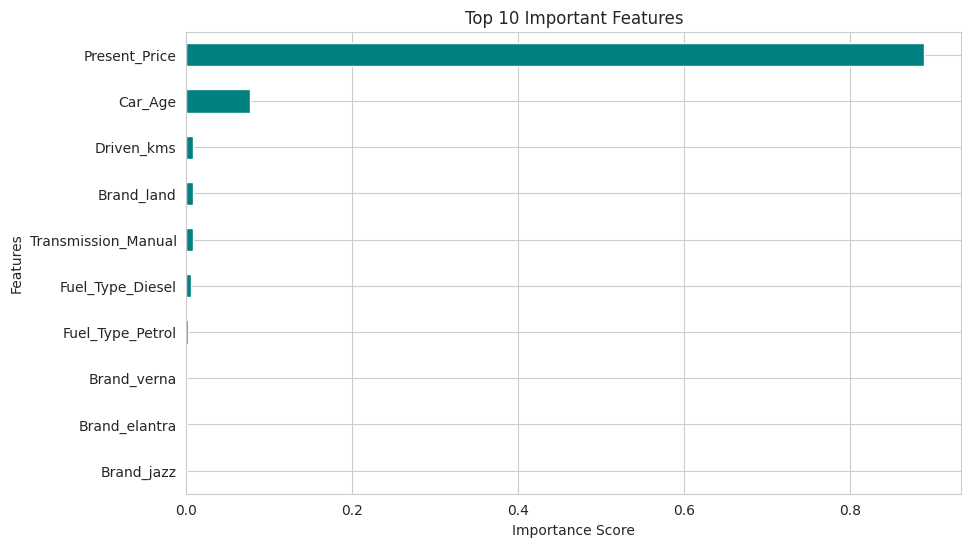

In [45]:
if hasattr(best_model, "feature_importances_"):

    plt.figure(figsize=(10,6))

    feature_importance.head(10).sort_values().plot(
        kind="barh",
        color="teal"
    )

    plt.title("Top 10 Important Features")

    plt.xlabel("Importance Score")

    plt.ylabel("Features")

    plt.show()

### Observation

- Features with higher importance scores contribute more to predicting the selling price.
- Understanding feature importance improves model interpretability.

# Actual vs Predicted Values

Comparing actual and predicted selling prices helps evaluate how well the selected model performs.

In [46]:
prediction_df = pd.DataFrame({

    "Actual Price": y_test.values,

    "Predicted Price": best_model.predict(X_test)

})

prediction_df.head(10)

,Actual Price,Predicted Price
0,8.99,9.174084
1,8.35,8.526126
2,0.45,0.536060
3,7.45,7.163323
4,5.25,15.501144
5,5.25,4.815556
6,5.85,5.324083
7,1.15,1.302422
8,9.25,8.600440
9,0.38,0.277253


# Scatter Plot: Actual vs Predicted

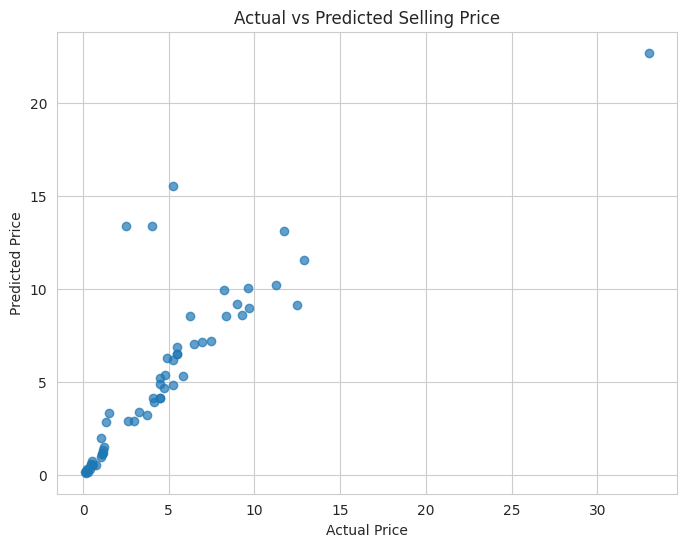

In [47]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    best_model.predict(X_test),
    alpha=0.7
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Selling Price")

plt.show()

### Observation

- If the points lie close to an imaginary diagonal line, the model predictions are accurate.
- Greater deviation from the line indicates larger prediction errors.

# Predicting a Sample Car Price

Let's predict the selling price of one car from the test dataset.

In [48]:
sample = X_test.iloc[[0]]

actual_price = y_test.iloc[0]

predicted_price = best_model.predict(sample)[0]

print("Actual Selling Price :", round(actual_price,2), "Lakhs")

print("Predicted Selling Price :", round(predicted_price,2), "Lakhs")

Actual Selling Price : 8.99 Lakhs
Predicted Selling Price : 9.17 Lakhs


# Key Insights

In [49]:
print("========== PROJECT INSIGHTS ==========\n")

print("Total Records :", df.shape[0])

print("Total Features :", df.shape[1])

print("\nBest Model :", best_model_name)

print("R² Score :", round(scores[best_model_name],3))

print("\nMost Important Features:")

if hasattr(best_model, "feature_importances_"):

    print(feature_importance.head(5))

========== PROJECT INSIGHTS ==========

Total Records : 299
Total Features : 52

Best Model : Gradient Boosting
R² Score : 0.704

Most Important Features:
Present_Price          0.889445
Car_Age                0.077060
Driven_kms             0.008264
Brand_land             0.008196
Transmission_Manual    0.007581
dtype: float64


# Conclusion

In this project, a machine learning solution was developed to predict the selling price of used cars.

The dataset was cleaned and preprocessed by handling duplicates, creating meaningful features such as **Car Age** and **Brand**, and encoding categorical variables.

Exploratory Data Analysis (EDA) revealed important relationships between selling price and factors such as present price, car age, fuel type, and transmission.

Three regression algorithms were trained and evaluated:

- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

The models were compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model was selected based on these evaluation metrics. Feature importance analysis further identified the variables that have the greatest influence on predicting car prices.

Overall, this project demonstrates how regression techniques can accurately estimate used car prices and highlights the importance of data preprocessing, feature engineering, and model evaluation in machine learning.